# TurtleBot3 - LiDAR attacked: precautionary stopScenario: `scenarios/turtlebot3_lidar_attacked_stop.yaml`

When the **own LiDAR is compromised** (`lidar_attacked:=true`), the bridge node does not
introduce the own readings (`w1/w2/w3`). Without reliable own data, the safety norm `SI2`
obliges a **precautionary stop** (`d_stop`).

- **w4**: robot in motion
- **w8**: untrusted peer
- **w9**: own LiDAR compromised

*Scenario originally authored by Diego Pastrana (University of Leon); edited and provided with Jupyter notebooks in this repository.*


In [ ]:
PATH = "../scenarios/turtlebot3_lidar_attacked_stop.yaml"

## Imports and utilities

In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))

from jiminy.engine import Jiminy
from jiminy.yaml_loader import load_scenario
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

def load(path=PATH):
    (pf, norms, contrariness, priorities, context_desc, norm_desc,
     contrariness_desc, priority_desc, base_priorities, meta_priorities) = load_scenario(path)
    return Jiminy(norms, contrariness, priorities, context_desc, norm_desc,
                  contrariness_desc, priority_desc, base_priorities, meta_priorities)

def run(facts, semantics="priority"):
    jim = load()
    args = jim.generate_arguments(facts)
    accepted, rejected = jim.compute_extension(args, semantics=semantics)
    decisions = sorted(a.hd for a in accepted if a.hd.startswith("d") or a.hd.startswith("p"))
    return decisions, jim, args, accepted, rejected

## Load the scenario

In [ ]:
jim = load()
print("Facts:", sorted(load_scenario(PATH)[0]))
print("Number of norms:", len(jim.norms))
print("Priorities:")
for k, v in sorted(jim.priorities.items()):
    print(f"  {k:<18} {v:>3}  - {jim.priority_desc.get(k, '')}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
Facts: ['w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8', 'w9']
Number of norms: 11
Priorities:
  d_ignore_peer        8  - Ignoring untrusted peer has high priority for security.
  d_move               2  - Free movement has the lowest priority.
  d_prefer_safe        7  - Conservative default has high priority.
  d_slow_down          6  - Slowing down has high priority — caution zone.
  d_stop              10  - Stopping has the highest priority — immediate safety.
  d_use_own_sensors    8  - Own sensor data is highly trusted when peer is compromised.
  p_continue           3  - Continuing movement has low priority compared to safety.


## Decision - Attack case

With the LiDAR compromised (`w9`) and in motion (`w4`), norm `SI2` derives **`d_stop`** as aprecaution. If additionally the peer is untrusted (`w8`), norms `CS2`/`CS3` activate`d_ignore_peer` and `d_use_own_sensors`.

In [ ]:
cases = {
    "Only LiDAR compromised": ['w4', 'w9'],
    "LiDAR + untrusted peer": ['w4', 'w8', 'w9']}

for name, facts in cases.items():
    decisions, _, _, _, _ = run(facts, "priority")
    print(f"{name:28s} {facts}  ->  {decisions}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000098 seconds
Only LiDAR compromised       ['w4', 'w9']  ->  ['d_prefer_safe', 'd_stop']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000079 seconds
LiDAR + untrusted peer       ['w4', 'w8', 'w9']  ->  ['d_ignore_peer', 'd_prefer_safe', 'd_stop', 'd_use_own_sensors']


## Narrative explanation

In [ ]:
facts = ['w4', 'w9']
decisions, jim, args, accepted, rejected = run(facts, "priority")
print(jim.explain(accepted, rejected, facts, semantics="priority"))

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000082 seconds
CONTEXT ANALYSIS
------------------------------------------------------------
 - w4
 - w9

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w9',) ⇒ i_no_own_data (Institutional fact, stakeholder=Safety)
 - ('i_no_own_data', 'w4') ⇒ d_stop (Obligation, stakeholder=Safety)
 - () ⇒ d_prefer_safe (Obligation, stakeholder=Manufacturer)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_stop conflicts with: d_slow_down, d_move
 - d_prefer_safe conflicts with: d_move

PRIORITY EVALUATION
------------------------------------------------------------
 - d_stop: 10
 - d_prefer_safe: 7

ACCEPTED ARGUMENTS
------------------------------------------------------------
 ✔ i_no_own_data accepted (institutional fact)
 ✔ d_stop accepted (stakeholder=Safety, priority=

## Argumentation attack diagram

Activating the full context lets all contrary decisions coexist, so everyattack (chi, red) and defeat (>, dashed blue) relation of the argumentationframework is drawn. Nodes with a double border are accepted by the `priority` semantics.

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000222 seconds
[Visualizer] Rendering graph → tb_stop_af.png


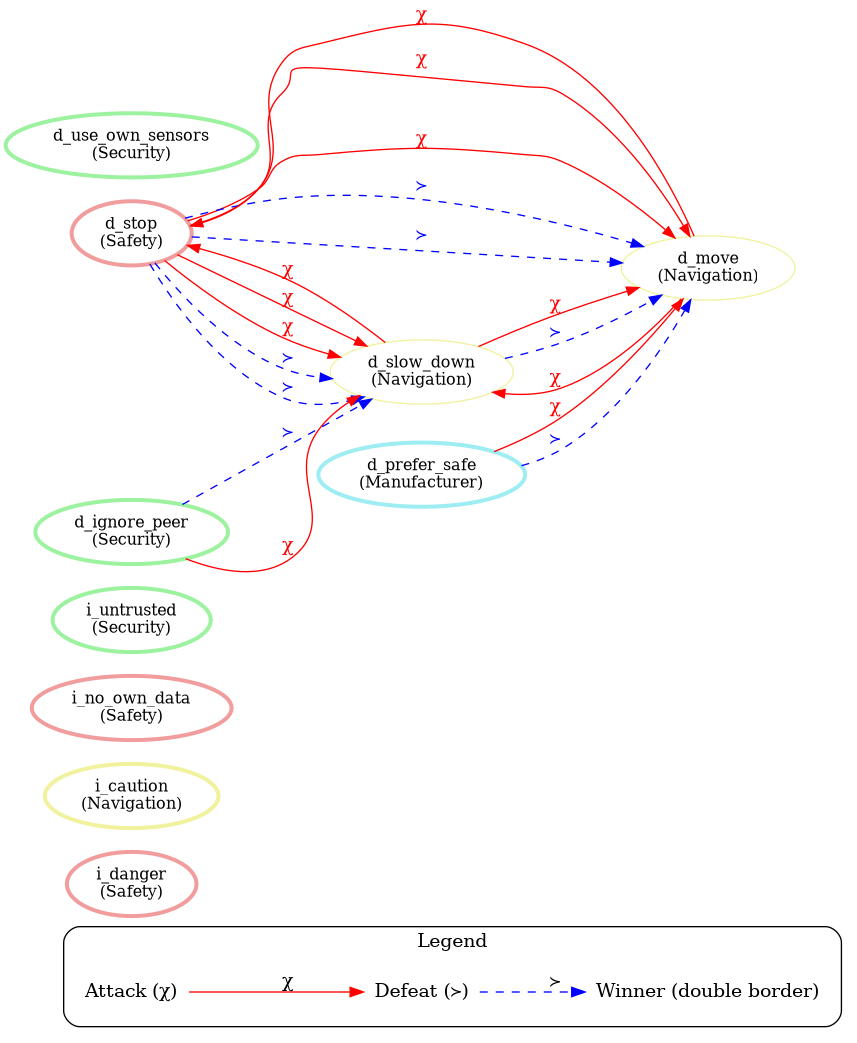


=== Attack relations present ===
  d_stop  <->  d_slow_down
  d_stop  <->  d_move
  d_slow_down  <->  d_stop
  d_slow_down  <->  d_move
  d_move  <->  d_stop
  d_move  <->  d_slow_down
  d_ignore_peer  <->  d_slow_down
  p_continue  <->  d_stop
  d_prefer_safe  <->  d_move


In [ ]:
from IPython.display import Image, display

jim = load()
all_facts = list(load_scenario(PATH)[0])
args = jim.generate_arguments(all_facts)
accepted, rejected = jim.compute_extension(args, semantics="priority")

av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in accepted},
                priorities=jim.priorities, contrariness=jim.contrariness)
name = "tb_stop_af"
av.render(name)
display(Image(filename=f"{name}.png"))

print("\n=== Attack relations present ===")
for src, contraries in jim.contrariness.items():
    for c in contraries:
        if c in {a.hd for a in args}:
            print(f"  {src}  <->  {c}")

## Graphviz Advanced Exports - Reasoning graph

Approach taken from the `jiminy_example` notebook (`export_reasoning_graph`, the 2nd figure).It shows the reasoning dependency chain: 
- facts (blue) -> institutional facts (green) ->decisions (orange = accepted, gray = rejected), 

with the norm descriptions as labels.A color legend is embedded in the graph.

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0


[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000130 seconds


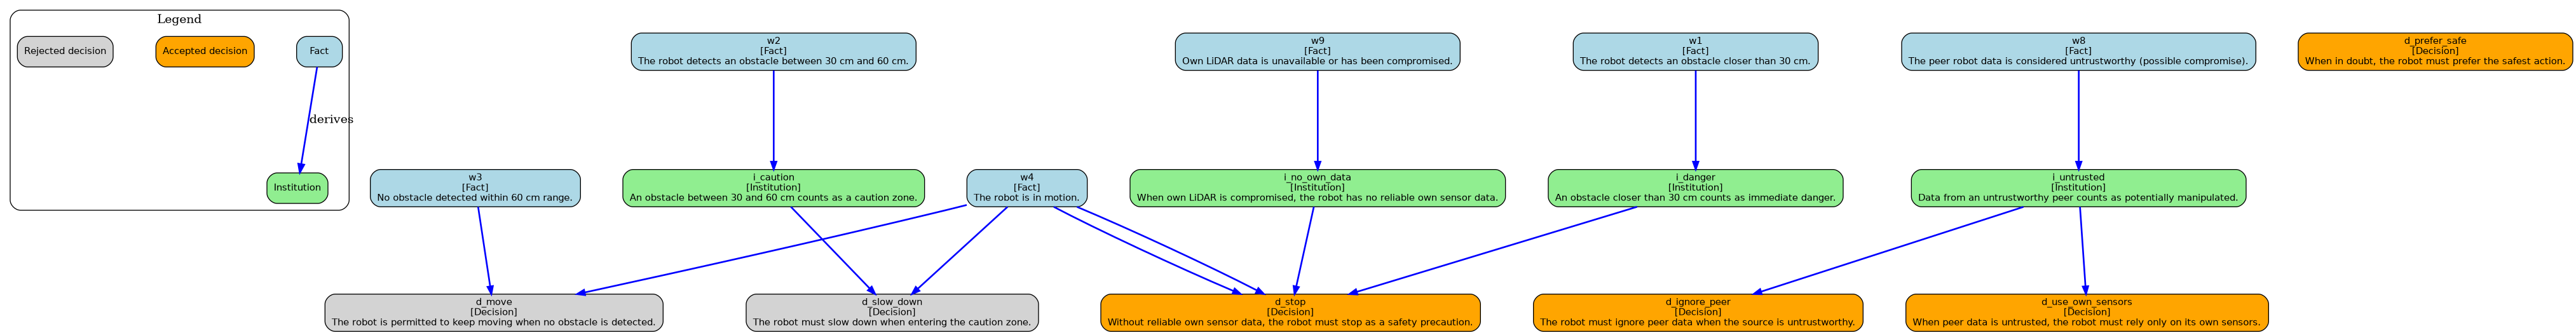

In [ ]:
# --- Graphviz Advanced Exports: reasoning graph (2nd figure of jiminy_example) ---
from graphviz import Digraph
from IPython.display import Image, display

# Build a label for each atom, attaching its textual description
def build_label(atom):
    if atom.startswith("w"):
        return f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}"
    if atom.startswith("i"):
        return f"{atom}\n[Institution]\n{jim.norm_desc.get(atom,'')}"
    if atom.startswith("d"):
        return f"{atom}\n[Decision]\n{jim.norm_desc.get(atom,'')}"
    return atom

def export_reasoning_graph(path):
    g = Digraph("Jiminy Reasoning", engine="dot")
    g.attr(rankdir="TB", ranksep="1.4", nodesep="0.7", splines="spline")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

    # Color legend so the diagram is easier to read
    with g.subgraph(name="cluster_legend") as legend:
        legend.attr(label="Legend", style="rounded", color="black", fontsize="14")
        legend.node("lg_fact", "Fact", fillcolor="lightblue")
        legend.node("lg_inst", "Institution", fillcolor="lightgreen")
        legend.node("lg_acc", "Accepted decision", fillcolor="orange")
        legend.node("lg_rej", "Rejected decision", fillcolor="lightgray")
        legend.edge("lg_fact", "lg_inst", color="blue", penwidth="2", label="derives")

    winners = {a.hd for a in accepted}
    facts, inst, decisions = set(), set(), set()
    edges = []

    # Collect nodes and derivation edges from every argument
    for a in args_final:
        head = a.hd
        if head.startswith("w"): facts.add(head)
        elif head.startswith("i"): inst.add(head)
        elif head.startswith("d"): decisions.add(head)

        body = getattr(a.origin_norm, "body", [])
        for b in body:
            edges.append((b, head))
            if b.startswith("w"): facts.add(b)
            elif b.startswith("i"): inst.add(b)
            elif b.startswith("d"): decisions.add(b)

    # Color nodes by type (facts / institutions / decisions)
    for w in facts: g.node(w, label=build_label(w), fillcolor="lightblue")
    for i in inst: g.node(i, label=build_label(i), fillcolor="lightgreen")
    for d in decisions:
        color = "orange" if d in winners else "lightgray"
        g.node(d, label=build_label(d), fillcolor=color)

    # Draw the derivation edges (body -> head)
    for a, b in edges: g.edge(a, b, color="blue", penwidth="2", arrowsize="0.9")

    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

# Rebuild the framework over the full context
jim = load()
all_facts = list(load_scenario(PATH)[0])
args_final = jim.generate_arguments(all_facts)
accepted, rejected = jim.compute_extension(args_final, semantics="priority")

display(Image(filename=export_reasoning_graph("tb_stop_reasoning")))